Data Handling
- Data Loading
- Data Inspection
- Data Cleaning
- Data Types

In [36]:
%pip install uv
%uv venv
%uv pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Using CPython 3.13.1 interpreter at: C:\Users\Ishaan Rastogi\AppData\Local\Programs\Python\Python313\python.exe
Creating virtual environment at: .venv
error: Failed to create virtual environment
  Caused by: A virtual environment already exists at `.venv`. Use `--clear` to replace it


Note: you may need to restart the kernel to use updated packages.


Using Python 3.13.1 environment at: C:\Users\Ishaan Rastogi\AppData\Local\Programs\Python\Python313
Checked 9 packages in 43ms


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('datasets/telco.csv')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [38]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [41]:
# I have to drop Lat Long column which is at 6th index

df = df.drop(columns=['Lat Long', 'Churn Label'])
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,89,5340,Competitor had better devices


In [42]:
# Removing the columns which have only one unique value
for i in df.columns:
    if df[i].nunique() == 1:
        df = df.drop(i, axis=1)

In [43]:
# To check the unique values in each column
for i in df.columns:
    print(f"{i} : {df[i].nunique()}")

CustomerID : 7043
City : 1129
Zip Code : 1652
Latitude : 1652
Longitude : 1651
Gender : 2
Senior Citizen : 2
Partner : 2
Dependents : 2
Tenure Months : 73
Phone Service : 2
Multiple Lines : 3
Internet Service : 3
Online Security : 3
Online Backup : 3
Device Protection : 3
Tech Support : 3
Streaming TV : 3
Streaming Movies : 3
Contract : 3
Paperless Billing : 2
Payment Method : 4
Monthly Charges : 1585
Total Charges : 6531
Churn Value : 2
Churn Score : 85
CLTV : 3438
Churn Reason : 20


In [44]:
df.head()

,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,89,5340,Competitor had better devices


## EDA

- ✅ Multivariate Analysis
- ✅ Correlation Analysis
- ✅ Pattern Discovery

In [47]:
df.head()

,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,89,5340,Competitor had better devices


### Multivariate Analysis

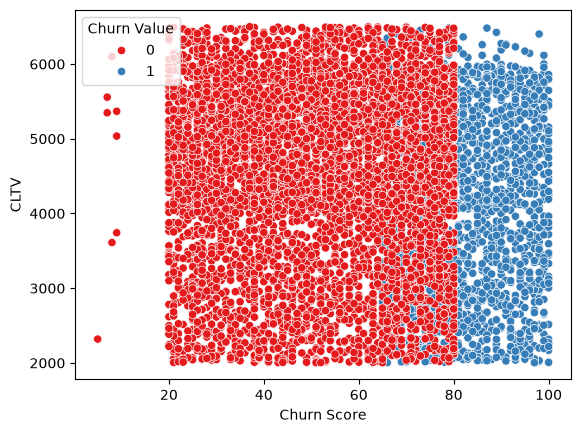

In [52]:
# Multivariate Analysis between Churn Value, Churn Score and CLTV

cols = ['Churn Value', 'Churn Score', 'CLTV']
sns.scatterplot(x=cols[1], y=cols[2], hue=cols[0], data=df, palette='Set1')
plt.show()

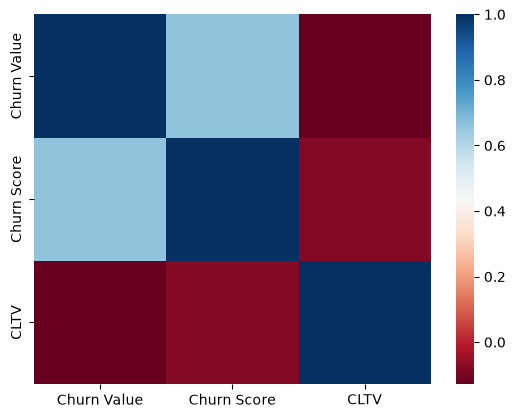

In [65]:
# Correlation between Churn Score and CLTV using heatmap
sns.heatmap(df[cols].corr(), cmap='RdBu')
plt.show()

<Axes: xlabel='Churn Score', ylabel='CLTV'>

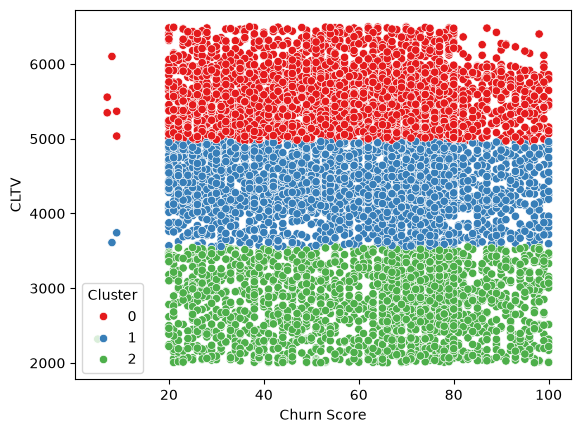

In [70]:
# To perform pattern discovery, we can use clustering techniques like KMeans
from sklearn.cluster import KMeans
df_cluster = df[['Churn Score', 'CLTV']]
k = KMeans(n_clusters=3, random_state=42)
k.fit(df_cluster)
df['Cluster'] = k.labels_

# Visualizing the clusters
sns.scatterplot(x= cols[1], y=cols[2], hue='Cluster', data = df, palette='Set1')

## Data Preprocessing
- ✅ Encoding
- ✅ Scaling
- ✅ Transformation
- ✅ Train/Test Split
- ✅ Feature Preparation

In [71]:
df.head()

,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Churn Reason,Cluster
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer,2
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701,Moved,2
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Month-to-month,Yes,Electronic check,99.65,820.5,1,86,5372,Moved,0
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003,Moved,0
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,89,5340,Competitor had better devices,0


In [72]:
# To check the unique values in each column
for i in df.columns:
    print(f"{i} : {df[i].nunique()}")

CustomerID : 7043
City : 1129
Zip Code : 1652
Latitude : 1652
Longitude : 1651
Gender : 2
Senior Citizen : 2
Partner : 2
Dependents : 2
Tenure Months : 73
Phone Service : 2
Multiple Lines : 3
Internet Service : 3
Online Security : 3
Online Backup : 3
Device Protection : 3
Tech Support : 3
Streaming TV : 3
Streaming Movies : 3
Contract : 3
Paperless Billing : 2
Payment Method : 4
Monthly Charges : 1585
Total Charges : 6531
Churn Value : 2
Churn Score : 85
CLTV : 3438
Churn Reason : 20
Cluster : 3


In [78]:
# Apply One-Hot Encoding to categorical (ordinal) columns like Gender, Senior Citizen, Partner, Dependents, Phone Service

from sklearn.preprocessing import OneHotEncoder

one_hot_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service']
one = OneHotEncoder(drop='first')
ar = one.fit_transform(df[one_hot_cols])
encoded_df = pd.DataFrame(ar.toarray().astype(int), columns=['Gender_female', 'Senior Citizen_No', 'Partner_No', 'Dependents_No', 'Phone Service_No'])
encoded_df.head()

,Gender_female,Senior Citizen_No,Partner_No,Dependents_No,Phone Service_No
0,1,0,0,0,1
1,0,0,0,1,1
2,0,0,0,1,1
3,0,0,1,1,1
4,1,0,0,1,1
